<div style='text-align: center; padding: 30px'>
  <h1><strong>Returns</strong></h1>
  <h3><strong>Heriberto Espino Montelongo</strong></h1>
</div>

In [72]:
import joypy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file = r'cryptos-index.csv'
data = pd.read_csv(file, index_col="Date", parse_dates=True)

In [74]:
returns = data.pct_change().dropna()            # Calculate returns

In [75]:
returns = returns.drop(columns='DAI')           # drop DAI, its too stable

In [85]:
returns = returns.drop(columns='TON')           # drop DAI, its too stable

In [86]:
returns_std = returns.std().sort_values().index # order them by the standard deviation
returns = returns[returns_std]                  # change the order of the columns

/home/codespace/.python/current/lib/python3.12/site-packages/joypy/joyplot.py:435: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  fig, axes = _subplots(naxes=num_axes, ax=ax, squeeze=False,


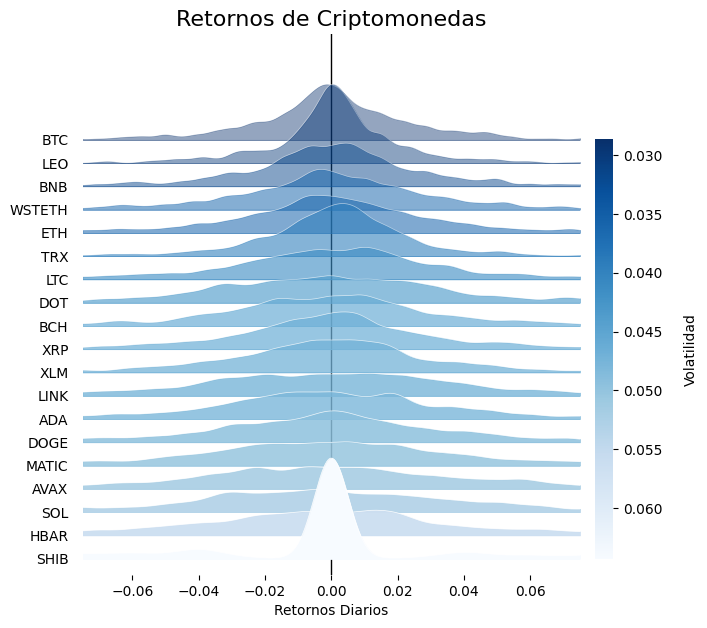

In [ ]:
# Calculate the variance of returns
returns_std = returns.std()

# Create a color palette based on the variance
cmap = sns.color_palette("Blues_r", as_cmap=True)
colors = [cmap(v) for v in (returns_std - returns_std.min()) / (returns_std.max() - returns_std.min())]

# Plot the joyplot with the new colors
fig, ax = plt.subplots(figsize=(6, 6))
joypy.joyplot(returns, overlap=1.5, fade=True, ax=ax, x_range=(-0.075, 0.075), color=colors, bw_method=0.08, linecolor='w', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=1)
plt.title('Retornos de Criptomonedas', fontsize=16)
plt.xlabel('Retornos Diarios')

# Add color bar to the right
norm = plt.Normalize(vmin=returns_std.min(), vmax=returns_std.max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Create a new axis for the color bar
cbar_ax = fig.add_axes([1, 0.1, 0.03, 0.7])  # [left, bottom, width, height]
cbar = plt.colorbar(sm, cax=cbar_ax, label='\nVolatilidad', orientation='vertical')
cbar.ax.yaxis.set_label_position('right')
cbar.ax.yaxis.set_ticks_position('right')

# Invert the color bar axis
cbar.ax.invert_yaxis()

# Remove the dark lines from the color bar
cbar.outline.set_edgecolor('none')

plt.savefig('svg/cryptos-joyplot.svg')
plt.show()